<a href="https://colab.research.google.com/github/pranay3318/Healthcare-Predictive-Analytics/blob/main/Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Dataset
df = pd.read_csv("diabetes.csv")

# Replace invalid zeros with NaN
columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for col in columns:
    df[col] = df[col].replace(0, np.nan)

# Fill missing values
for col in columns:
    df[col] = df[col].fillna(df[col].median())

# Features and Target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)
print("Preprocessing Completed")

Preprocessing Completed


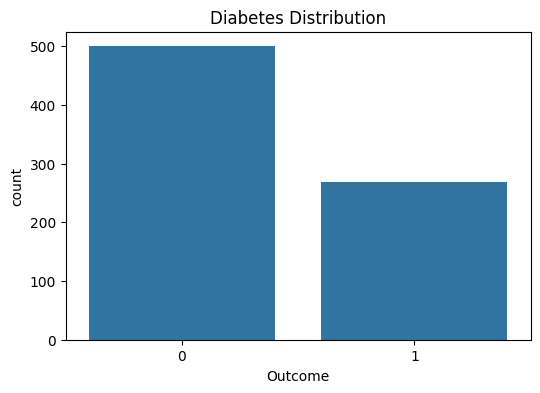

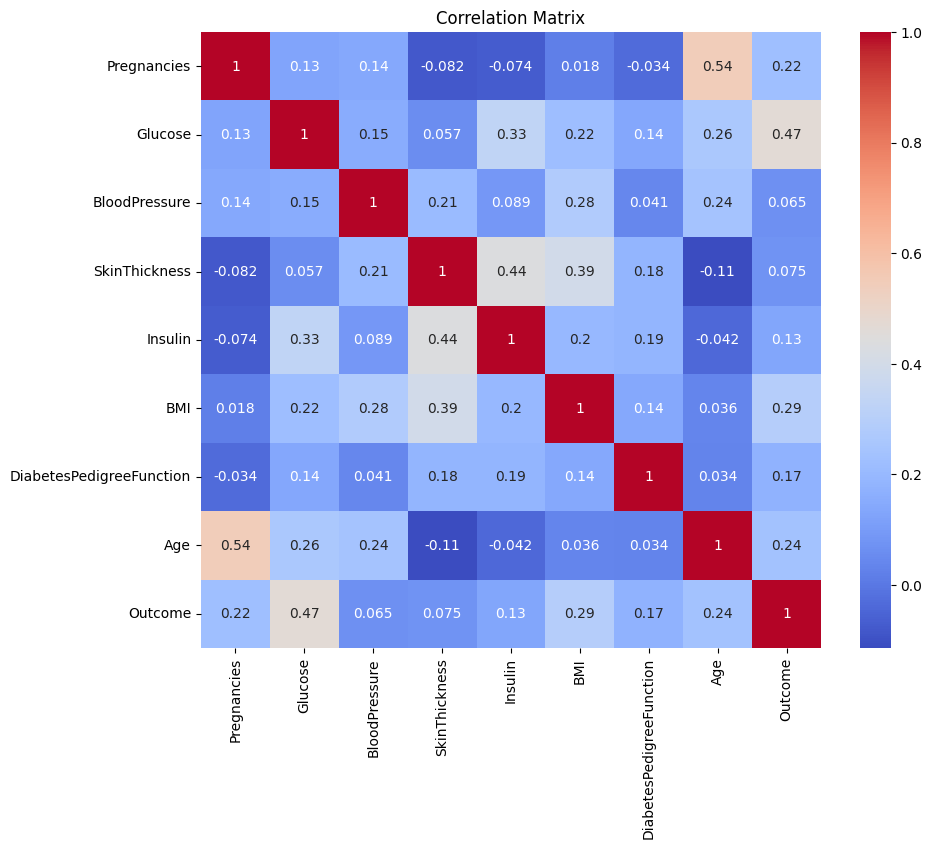

In [17]:
#Visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes.csv")

# Outcome Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [18]:
#logistic_regression_model
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

df = pd.read_csv("diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, pred))

print(classification_report(
    y_test,
    pred
))

Accuracy: 0.7532467532467533
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



In [19]:
#decision_tree_model
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

df = pd.read_csv("diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, pred))

print(classification_report(
    y_test,
    pred
))

Accuracy: 0.7922077922077922
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        99
           1       0.74      0.64      0.69        55

    accuracy                           0.79       154
   macro avg       0.78      0.76      0.77       154
weighted avg       0.79      0.79      0.79       154



Accuracy: 0.7337662337662337
              precision    recall  f1-score   support

           0       0.80      0.79      0.79        99
           1       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



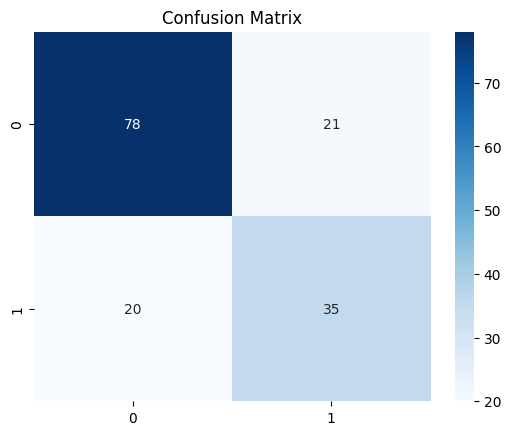

In [20]:
#random_forest_model
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, pred))

print(classification_report(
    y_test,
    pred
))

cm = confusion_matrix(y_test, pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.show()

                    Feature  Importance
1                   Glucose    0.252102
5                       BMI    0.170029
7                       Age    0.147700
6  DiabetesPedigreeFunction    0.120429
2             BloodPressure    0.089049
0               Pregnancies    0.077401
4                   Insulin    0.077176
3             SkinThickness    0.066114


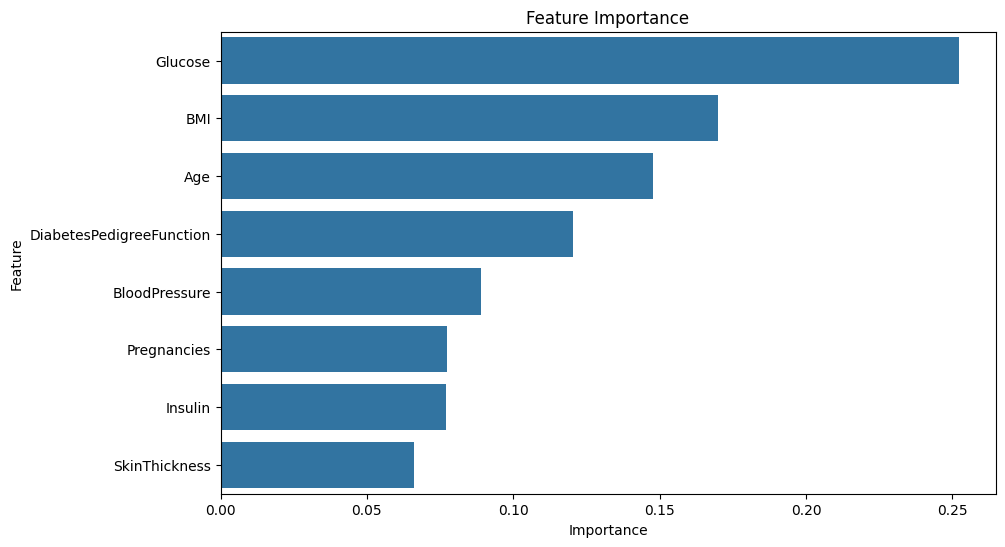

In [21]:
#feature importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

importance = rf.feature_importances_

feature_df = pd.DataFrame({
    'Feature': df.drop('Outcome', axis=1).columns,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_df)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df
)

plt.title("Feature Importance")
plt.show()

In [22]:
#predict patient
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_scaled, y)

# Sample Patient
# Get feature names from the original DataFrame
feature_names = X.columns

patient_data = [
    [5, 140, 80, 25, 120, 30.5, 0.45, 45]
]

# Create a DataFrame for the patient with the correct column names
patient_df = pd.DataFrame(patient_data, columns=feature_names)

patient_scaled = scaler.transform(patient_df)

prediction = model.predict(
    patient_scaled
)

probability = model.predict_proba(
    patient_scaled
)

if prediction[0] == 1:
    print("High Risk of Diabetes")
else:
    print("Low Risk of Diabetes")

print(
    "Risk Score:",
    round(probability[0][1] * 100, 2),
    "%"
)


High Risk of Diabetes
Risk Score: 60.5 %
